# HyperSense — Exploratory Data Analysis (EDA)

## Objective

Explore the harmonized Ghana–Benin hypertension dataset to:

- Understand the distribution of key variables
- Assess data quality and missingness
- Examine hypertension prevalence patterns
- Compare demographic, behavioral, and clinical characteristics
- Create analytical features for modelling
- Identify relationships between predictors and hypertension status

## Dataset Summary

The harmonized dataset contains respondents from:

- Ghana DHS 2014 Men (MR)
- Ghana DHS 2014 Women (IR)
- Benin DHS 2017–18 Men (MR)
- Benin DHS 2017–18 Women (IR)

Target variable:

- `htn_status`
    - 1 = Hypertensive
    - 0 = Non-hypertensive

## Workflow

1. Dataset overview
2. Missingness assessment
3. Target variable exploration
4. Demographic analysis
5. Clinical variable analysis
6. Behavioral risk factor analysis
7. Correlation analysis
8. Feature Engineering & Modelling Preparation
9. EDA summary and modelling recommendations

## Expected Output

A cleaned analytical dataset, key exploratory insights, engineered features, and evidence-based recommendations for machine learning model development.

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### STEP 1: Dataset Overview

In [276]:
# Load the dataset
master_df = pd.read_csv('../outputs/hypersense_master.csv')

In [277]:
# Dataset dimensions and preview
print(f"Dataset shape: {master_df.shape}")
master_df.head()

Dataset shape: (37307, 27)


,caseid,cluster,household,respondent_number,sample_weight,age,educational_level,residence,smokes_cig,smokes_pipe,...,sbp_1,sbp_2,dbp_1,dbp_2,mean_sbp,mean_dbp,gender,country,htn_status,tobacco_use
0,1 1 1,1.0,1.0,1.0,856663.0,50.0,2,0,0.0,0.0,...,152.0,154.0,106.0,101.0,153.0,103.5,1,Ghana,1.0,0
1,1 3 1,1.0,3.0,1.0,856663.0,27.0,2,0,0.0,0.0,...,133.0,136.0,79.0,82.0,134.5,80.5,1,Ghana,0.0,0
2,1 6 1,1.0,6.0,1.0,856663.0,24.0,2,0,0.0,0.0,...,109.0,108.0,63.0,63.0,108.5,63.0,1,Ghana,0.0,0
3,111 1,1.0,11.0,1.0,856663.0,40.0,1,0,0.0,0.0,...,117.0,117.0,84.0,82.0,117.0,83.0,1,Ghana,0.0,1
4,119 1,1.0,19.0,1.0,856663.0,43.0,2,0,0.0,0.0,...,131.0,121.0,85.0,80.0,126.0,82.5,1,Ghana,0.0,0


In [278]:
# List all variables

print(f"Number of variables: {len(master_df.columns)}")
master_df.columns.tolist()

Number of variables: 27


['caseid',
 'cluster',
 'household',
 'respondent_number',
 'sample_weight',
 'age',
 'educational_level',
 'residence',
 'smokes_cig',
 'smokes_pipe',
 'chews_tobacco',
 'uses_snuff',
 'smokes_other',
 'smokes_none',
 'freq_smoke_tobacco',
 'freq_smokeless_tobacco',
 'bmi',
 'sbp_1',
 'sbp_2',
 'dbp_1',
 'dbp_2',
 'mean_sbp',
 'mean_dbp',
 'gender',
 'country',
 'htn_status',
 'tobacco_use']

In [279]:
# ==================================================
# Inspect variable types and completeness
# ==================================================

master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37307 entries, 0 to 37306
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   caseid                  37307 non-null  object 
 1   cluster                 37307 non-null  float64
 2   household               37307 non-null  float64
 3   respondent_number       37307 non-null  float64
 4   sample_weight           37307 non-null  float64
 5   age                     37307 non-null  float64
 6   educational_level       37307 non-null  int64  
 7   residence               37307 non-null  int64  
 8   smokes_cig              29708 non-null  float64
 9   smokes_pipe             29707 non-null  float64
 10  chews_tobacco           29707 non-null  float64
 11  uses_snuff              29707 non-null  float64
 12  smokes_other            29707 non-null  float64
 13  smokes_none             29708 non-null  float64
 14  freq_smoke_tobacco      23523 non-null

In [280]:
# ==================================================
# Summary statistics for numeric variables
# ==================================================

master_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cluster,37307.0,2.415115e+02,152.242702,1.0,110.0,231.0,361.0,555.0
household,37307.0,5.485635e+01,55.326367,1.0,16.0,31.0,82.0,1210.0
respondent_number,37307.0,2.849170e+00,2.796442,1.0,1.0,2.0,3.0,42.0
sample_weight,37307.0,1.000000e+06,534907.663919,94252.0,661645.0,921036.0,1208372.0,5980193.0
age,37307.0,2.989149e+01,10.730418,15.0,21.0,28.0,38.0,64.0
educational_level,37307.0,1.074865e+00,0.974448,0.0,0.0,1.0,2.0,3.0
residence,37307.0,4.578229e-01,0.498225,0.0,0.0,0.0,1.0,1.0
smokes_cig,29708.0,1.595530e-02,0.125305,0.0,0.0,0.0,0.0,1.0
smokes_pipe,29707.0,9.762009e-04,0.031229,0.0,0.0,0.0,0.0,1.0
chews_tobacco,29707.0,2.221699e-03,0.047083,0.0,0.0,0.0,0.0,1.0


In [281]:
# Respondents by country
master_df["country"].value_counts()

country
Benin    23523
Ghana    13784
Name: count, dtype: int64

In [282]:
# Respondents by gender
master_df["gender"].value_counts()

gender
0    25324
1    11983
Name: count, dtype: int64

In [283]:
# Respondents by country and gender
pd.crosstab(
    master_df["country"],
    master_df["gender"]
)

gender,0,1
country,,
Benin,15928,7595
Ghana,9396,4388


In [284]:
# ==================================================
# Percentage missing for each variable
# ==================================================

missing_pct = (
    master_df
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing_pct.to_frame("missing_pct")

,missing_pct
sbp_2,63.165090
dbp_2,63.165090
dbp_1,63.157048
sbp_1,63.157048
bmi,57.321682
mean_sbp,45.195272
htn_status,45.195272
mean_dbp,45.189911
freq_smoke_tobacco,36.947490
freq_smokeless_tobacco,36.947490


In [285]:
# Taking a deeper look at bmi
print(master_df["bmi"].value_counts().sort_index().tail(15))
master_df.bmi.describe().T.to_frame('value')

bmi
4802.0    1
4853.0    1
4869.0    1
4884.0    1
4901.0    1
4920.0    1
4984.0    1
5007.0    1
5030.0    1
5035.0    1
5129.0    1
5324.0    1
5435.0    1
5706.0    1
9998.0    6
Name: count, dtype: int64


,value
count,15922.000000
mean,2340.958108
std,489.667466
min,1320.000000
25%,2022.000000
50%,2232.000000
75%,2542.000000
max,9998.000000


In [286]:
# ==============================================
# Fix DHS special BMI codes
# ==============================================

# Recode DHS special BMI values (9998) to missing
master_df["bmi"] = master_df["bmi"].replace(9998, np.nan)

# Verify correction
master_df["bmi"].describe().to_frame('value')

,value
count,15916.000000
mean,2338.071563
std,466.639588
min,1320.000000
25%,2022.000000
50%,2232.000000
75%,2541.250000
max,5706.000000


#### Key Dataset Facts

The harmonized HyperSense dataset contains **37,307 respondents** and **26 variables** pooled from four DHS surveys:

| Dataset | n |
|----------|----------:|
| Ghana Men | 4,388 |
| Ghana Women | 9,396 |
| Benin Men | 7,595 |
| Benin Women | 15,928 |

**Population Profile:**
- Mean age: **29.9 years**
- Age range: **15–64 years**
- Female respondents: **25,324 (67.9%)**
- Male respondents: **11,983 (32.1%)**

**Blood Pressure Coverage:** Hypertension status was available for **20,446 respondents (54.8%)**, while **16,861 (45.2%)** had no BP measurements due to DHS survey design and module differences.

**Missingness Summary:** Missing values were concentrated in the following Blood pressure variables, BMI, and Tobacco frequency variables.

These patterns largely reflect differences in DHS data collection procedures rather than data processing errors. The final modeling dataset will be restricted to respondents with valid hypertension outcome measurements.

#### STEP 2: Missingness Assessment

In [287]:
# Missingness summary
missing_pct.to_frame('missing_pct')

,missing_pct
sbp_2,63.165090
dbp_2,63.165090
dbp_1,63.157048
sbp_1,63.157048
bmi,57.321682
mean_sbp,45.195272
htn_status,45.195272
mean_dbp,45.189911
freq_smoke_tobacco,36.947490
freq_smokeless_tobacco,36.947490


In [288]:
# % Missing HTN status by country and sex
(
    master_df
    .groupby(["country", "gender"])["htn_status"]
    .apply(lambda x: x.isna().mean() * 100)
    .to_frame("missing_htn_pct")
)

missing_htn_pct
country gender                 
Benin   0             80.769714
        1             52.113232
Ghana   0              0.287356
        1              0.250684

In [289]:
# Available BP measurements by country and sex
(
    master_df
    .groupby(["country", "gender"])["htn_status"]
    .count()
    .to_frame("measured_respondents")
)

measured_respondents
country gender                      
Benin   0                       3063
        1                       3637
Ghana   0                       9369
        1                       4377

#### Missingness Assessment

Missingness was concentrated in blood pressure, BMI, and tobacco frequency variables. These patterns were expected and primarily reflect differences in DHS survey modules across countries and sexes rather than data processing issues.

Hypertension status was available for 20,446 respondents. Coverage was highest in Ghana and substantially lower in Benin, particularly among women. Consequently, the final modelling dataset will be restricted to respondents with valid hypertension outcome measurements.

#### STEP 3: Target Variable Exploration

In [290]:
# Overall hypertension prevalence
htn_counts = master_df["htn_status"].value_counts(dropna=False)
htn_pct = master_df["htn_status"].value_counts(normalize=True, dropna=False) * 100

print(htn_counts.to_frame('Counts'))
print()
print(htn_pct.round(2).to_frame('Percentages'))

            Counts
htn_status        
0.0          18097
NaN          16861
1.0           2349

            Percentages
htn_status             
0.0               48.51
NaN               45.20
1.0                6.30


In [291]:
# Hypertension prevalence among measured respondents
measured_df = master_df.dropna(subset=["htn_status"])

(
    measured_df["htn_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("prevalence_pct")
)

,prevalence_pct
htn_status,
0.0,88.51
1.0,11.49


In [292]:
# HTN prevalence by country and sex among measured respondents
(
    measured_df
    .groupby(["country", "gender"], observed=True)["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

htn_prevalence_pct
country gender                    
Benin   0                    12.90
        1                    16.47
Ghana   0                     9.01
        1                    11.67

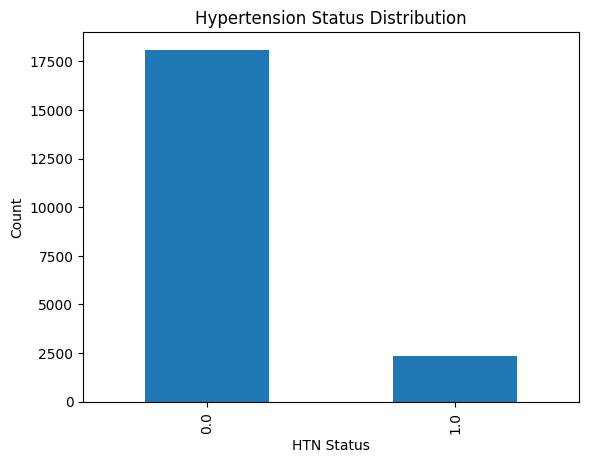

In [293]:
# Overall HTN distribution
(
    measured_df["htn_status"]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Hypertension Status Distribution")
plt.xlabel("HTN Status")
plt.ylabel("Count")
plt.show()

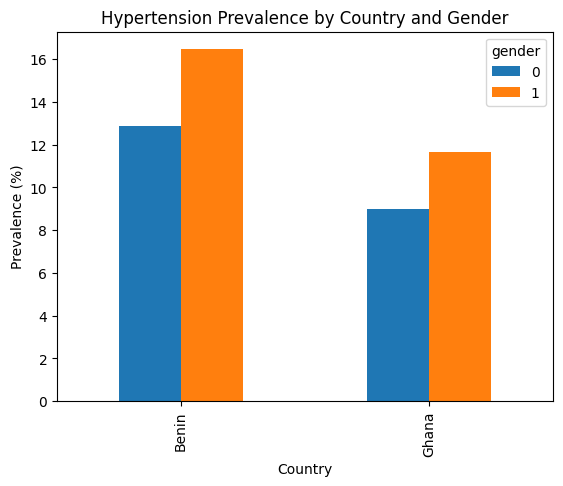

In [294]:
# HTN prevalence by country and sex
(
    measured_df
    .groupby(["country", "gender"])["htn_status"]
    .mean()
    .mul(100)
    .unstack()
    .plot(kind="bar")
)

plt.title("Hypertension Prevalence by Country and Gender")
plt.ylabel("Prevalence (%)")
plt.xlabel("Country")
plt.show()

In [295]:
# ==================================================
# Keep respondents with valid HTN outcome
# ==================================================

model_df = master_df.dropna(subset=["htn_status"]).copy()

print(model_df.shape)

(20446, 27)


### Key Findings

A total of 20,446 respondents had valid blood pressure measurements and hypertension classifications available for analysis.

Overall hypertension prevalence among measured respondents was **11.49%**, while **88.51%** were classified as non-hypertensive. This indicates a moderately imbalanced target variable that should be considered during model evaluation and training.

Hypertension prevalence differed across countries and sexes. Benin recorded higher prevalence than Ghana for both males and females, while males consistently showed higher prevalence than females within each country.

The highest prevalence was observed among **Benin males (16.47%)**, whereas the lowest prevalence was observed among **Ghana females (9.01%)**. These patterns suggest that demographic and geographic factors may contribute meaningfully to hypertension risk and should be explored further during feature analysis and model development.

#### STEP 4: Demographic Analysis

In [296]:
# Age distribution by hypertension status
model_df.groupby("htn_status")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
htn_status,,,,,,,,
0.0,18097.0,32.731668,10.735329,15.0,24.0,33.0,40.0,64.0
1.0,2349.0,41.134951,9.417856,15.0,35.0,42.0,48.0,64.0


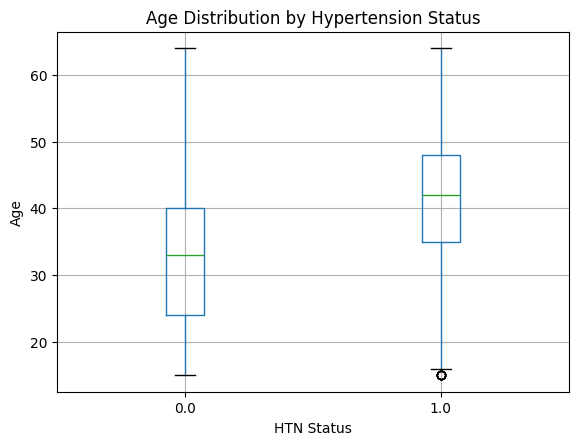

In [297]:
# Age visualization by hypertension status

model_df.boxplot(column="age", by="htn_status")

plt.title("Age Distribution by Hypertension Status")
plt.suptitle("")
plt.xlabel("HTN Status")
plt.ylabel("Age")
plt.show()

In [298]:
# HTN prevalence by gender
(
    model_df
    .groupby("gender")["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

,htn_prevalence_pct
gender,
0,9.97
1,13.85


In [299]:
# Gender distribution by HTN status
pd.crosstab(
    model_df["gender"],
    model_df["htn_status"],
    normalize="index"
).round(4) * 100

htn_status,0.0,1.0
gender,,
0,90.03,9.97
1,86.15,13.85


In [300]:
# HTN prevalence by residence
(
    model_df
    .groupby("residence")["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

,htn_prevalence_pct
residence,
0,9.54
1,13.68


In [301]:
# Residence distribution by HTN status
pd.crosstab(
    model_df["residence"],
    model_df["htn_status"],
    normalize="index"
) * 100

htn_status,0.0,1.0
residence,,
0,90.457275,9.542725
1,86.321588,13.678412


In [302]:
# HTN prevalence by education level
(
    model_df
    .groupby("educational_level")["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

,htn_prevalence_pct
educational_level,
0,11.25
1,11.48
2,11.26
3,14.42


In [303]:
# HTN prevalence by country
(
    model_df
    .groupby("country")["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

,htn_prevalence_pct
country,
Benin,14.84
Ghana,9.86


In [304]:
# HTN prevalence by country and gender
(
    model_df
    .groupby(["country", "gender"])["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

htn_prevalence_pct
country gender                    
Benin   0                    12.90
        1                    16.47
Ghana   0                     9.01
        1                    11.67

#### Key Findings

Respondents with hypertension were substantially older than those without hypertension (41.1 vs 32.7 years). Hypertension prevalence was higher among males than females (13.9% vs 10.0%) and higher among urban residents than rural residents (13.7% vs 9.5%). Age appears to be the strongest demographic predictor of hypertension in this dataset.

#### STEP 5: Clinical variable analysis

In [305]:
# Clinical variable summary statistics
clinical_vars = [
    "bmi",
    "mean_sbp",
    "mean_dbp"
]

model_df[clinical_vars].describe().T

,count,mean,std,min,25%,50%,75%,max
bmi,7844.0,2354.533911,454.071756,1334.0,2043.0,2253.0,2559.0,5435.0
mean_sbp,20446.0,114.634452,16.992510,0.0,103.5,112.0,122.0,246.0
mean_dbp,20446.0,74.663308,11.557919,0.0,67.0,73.5,81.0,148.0


In [306]:
# Clinical variables by HTN status

(
    model_df
    .groupby("htn_status")[clinical_vars]
    .agg(["mean", "median", "std"])
    .round(2)
)

bmi                 mean_sbp               mean_dbp         \
               mean  median     std     mean median    std     mean median   
htn_status                                                                   
0.0         2322.04  2230.0  430.31   110.48  110.0  11.38    71.99   72.0   
1.0         2603.69  2505.0  545.38   146.64  144.0  18.96    95.26   94.0   

                  
             std  
htn_status        
0.0          8.6  
1.0         10.7

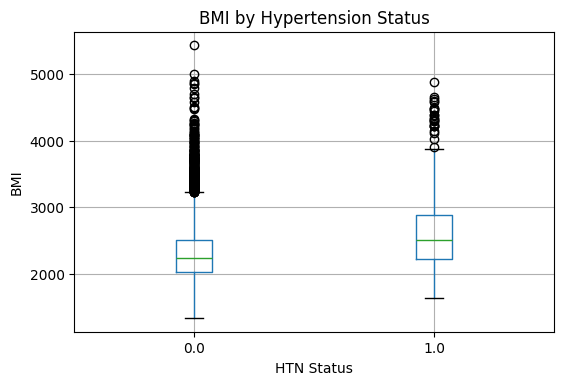

In [307]:
# BMI distribution by HTN status
model_df.boxplot(
    column="bmi",
    by="htn_status",
    figsize=(6, 4)
)

plt.title("BMI by Hypertension Status")
plt.suptitle("")
plt.xlabel("HTN Status")
plt.ylabel("BMI")
plt.show()

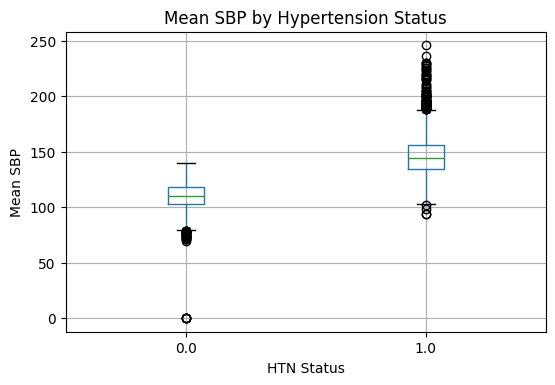

In [308]:
# Mean SBP by HTN status
model_df.boxplot(
    column="mean_sbp",
    by="htn_status",
    figsize=(6, 4)
)

plt.title("Mean SBP by Hypertension Status")
plt.suptitle("")
plt.xlabel("HTN Status")
plt.ylabel("Mean SBP")
plt.show()

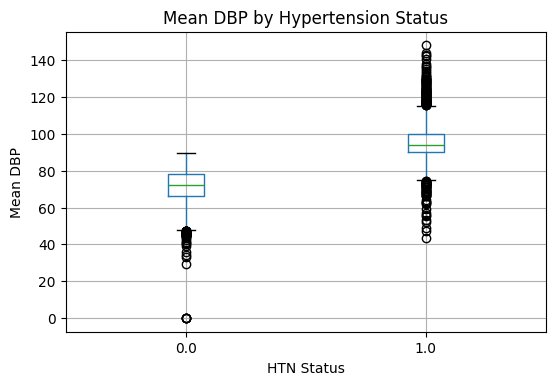

In [309]:
# Mean DBP by HTN status
model_df.boxplot(
    column="mean_dbp",
    by="htn_status",
    figsize=(6, 4)
)

plt.title("Mean DBP by Hypertension Status")
plt.suptitle("")
plt.xlabel("HTN Status")
plt.ylabel("Mean DBP")
plt.show()

In [310]:
# Clinical variable correlation with HTN status
(
    model_df[
        ["bmi", "mean_sbp", "mean_dbp", "htn_status"]
    ]
    .corr(numeric_only=True)[["htn_status"]]
    .sort_values("htn_status", ascending=False)
)

,htn_status
htn_status,1.000000
mean_sbp,0.678533
mean_dbp,0.641977
bmi,0.198174


#### Key Findings

Respondents with hypertension had substantially higher BMI, systolic blood pressure, and diastolic blood pressure values than those without hypertension. The strongest associations with hypertension status were observed for mean systolic blood pressure (r = 0.68) and mean diastolic blood pressure (r = 0.64), while BMI showed a weaker but positive relationship (r = 0.20). Blood pressure variables clearly provide the dominant clinical signal within the dataset.

#### STEP 6: Behavioural risk factor analysis

In [311]:
# Tobacco use prevalence

(
    model_df["tobacco_use"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

,percentage
tobacco_use,
0,94.09
1,5.91


In [312]:
# Tobacco use distribution by HTN status

pd.crosstab(
    model_df["tobacco_use"],
    model_df["htn_status"],
    normalize="index"
).round(4) * 100

htn_status,0.0,1.0
tobacco_use,,
0,88.78,11.22
1,84.28,15.72


In [313]:
# HTN prevalence by tobacco use

(
    model_df
    .groupby("tobacco_use")["htn_status"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("htn_prevalence_pct")
)

,htn_prevalence_pct
tobacco_use,
0,11.22
1,15.72


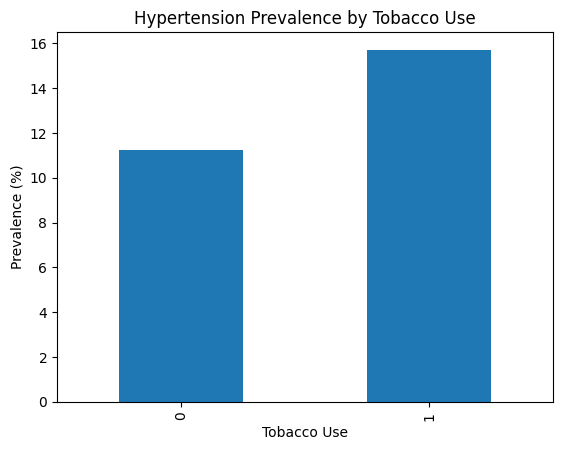

In [314]:
# HTN prevalence by tobacco use

(
    model_df
    .groupby("tobacco_use")["htn_status"]
    .mean()
    .mul(100)
    .plot(kind="bar")
)

plt.title("Hypertension Prevalence by Tobacco Use")
plt.xlabel("Tobacco Use")
plt.ylabel("Prevalence (%)")
plt.show()

In [315]:
# Correlation with HTN status

(
    model_df[["tobacco_use", "htn_status"]]
    .corr(numeric_only=True)[["htn_status"]]
)

,htn_status
tobacco_use,0.033228
htn_status,1.000000


In [316]:
# Tobacco use by gender
(
    model_df
    .groupby("gender")["tobacco_use"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("tobacco_use_pct")
)

,tobacco_use_pct
gender,
0,1.28
1,13.10


In [317]:
# Tobacco use by residence type
(
    model_df
    .groupby("residence")["tobacco_use"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("tobacco_use_pct")
)

,tobacco_use_pct
residence,
0,7.65
1,3.96


#### Key Findings

Tobacco use was uncommon (5.9%) but was associated with a higher prevalence of hypertension (15.7% vs 11.2% among non-users). Tobacco use was substantially more common among males (13.1% vs 1.3%) and rural residents (7.7% vs 4.0%). Although its direct correlation with hypertension was weak (r = 0.03), tobacco use remains a clinically relevant behavioural risk factor.

#### STEP 7: Correlation Analysis

In [318]:
# Variables selected for correlation analysis

corr_vars = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "bmi",
    "tobacco_use",
    "htn_status"
]
corr_df = model_df[corr_vars].copy()

In [319]:
# Correlation matrix for all modelling variables

corr_df.corr(numeric_only=True).round(3)

,age,gender,residence,educational_level,bmi,tobacco_use,htn_status
age,1.000,0.225,-0.016,-0.294,0.177,0.190,0.245
gender,0.225,1.000,-0.022,0.067,-0.223,0.245,0.059
residence,-0.016,-0.022,1.000,0.277,0.229,-0.078,0.065
educational_level,-0.294,0.067,0.277,1.000,0.121,-0.176,0.011
bmi,0.177,-0.223,0.229,0.121,1.000,-0.123,0.198
tobacco_use,0.190,0.245,-0.078,-0.176,-0.123,1.000,0.033
htn_status,0.245,0.059,0.065,0.011,0.198,0.033,1.000


In [320]:
# Correlation of each feature with hypertension status

(
    corr_df
    .corr(numeric_only=True)[["htn_status"]]
    .sort_values("htn_status", ascending=False)
    .round(3)
)

,htn_status
htn_status,1.000
age,0.245
bmi,0.198
residence,0.065
gender,0.059
tobacco_use,0.033
educational_level,0.011


In [321]:
# Correlation matrix excluding target variable..
# to assess multicollinearity

predictor_vars = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "bmi",
    "tobacco_use"
]

(
    model_df[predictor_vars]
    .corr(numeric_only=True)
    .round(3)
)

,age,gender,residence,educational_level,bmi,tobacco_use
age,1.000,0.225,-0.016,-0.294,0.177,0.190
gender,0.225,1.000,-0.022,0.067,-0.223,0.245
residence,-0.016,-0.022,1.000,0.277,0.229,-0.078
educational_level,-0.294,0.067,0.277,1.000,0.121,-0.176
bmi,0.177,-0.223,0.229,0.121,1.000,-0.123
tobacco_use,0.190,0.245,-0.078,-0.176,-0.123,1.000


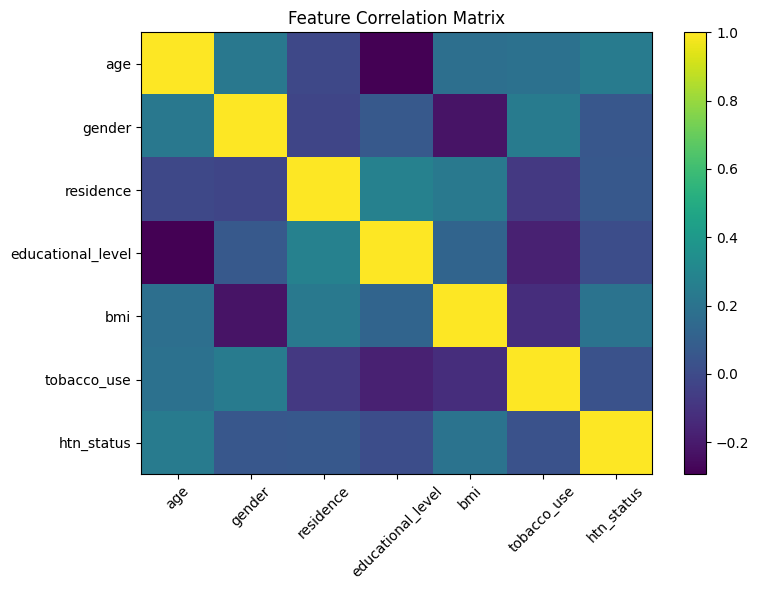

In [322]:
# Visualisation of feature correlations

corr_matrix = corr_df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))

plt.imshow(
    corr_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [323]:
# Ranking predictors by absolute correlation with hypertension..
# though no variable has negative correlation with the target

(
    corr_df
    .corr(numeric_only=True)[["htn_status"]]
    # .drop(index="htn_status")
    .assign(abs_corr=lambda x: x["htn_status"].abs())
    .sort_values("abs_corr", ascending=False)
    .round(3)
)

,htn_status,abs_corr
htn_status,1.000,1.000
age,0.245,0.245
bmi,0.198,0.198
residence,0.065,0.065
gender,0.059,0.059
tobacco_use,0.033,0.033
educational_level,0.011,0.011


## Key Findings

Age (r = 0.245) and BMI (r = 0.198) showed the strongest positive correlations with hypertension status, although all observed correlations were relatively weak to moderate. Residence, gender, and tobacco use demonstrated smaller positive associations, while educational level showed minimal correlation with hypertension.

Correlations among predictor variables were generally low (|r| < 0.30), indicating little evidence of multicollinearity. This supports retaining all candidate predictors for subsequent model development.

#### STEP 8: Feature Engineering & Modelling Preparation

In [324]:
# Final candidate predictors selected from EDA

feature_cols = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "bmi",
    "tobacco_use"
]

target_col = "htn_status"

In [325]:
# Missingness assessment for modelling variables

(
    model_df[feature_cols + [target_col]]
    .isnull()
    .sum()
    .to_frame("missing_count")
)

,missing_count
age,0
gender,0
residence,0
educational_level,0
bmi,12602
tobacco_use,0
htn_status,0


In [326]:
# Missingness percentage for modelling variables

(
    model_df[feature_cols + [target_col]]
    .isnull()
    .mean()
    .mul(100)
    .round(2)
    .to_frame("missing_pct")
)

,missing_pct
age,0.00
gender,0.00
residence,0.00
educational_level,0.00
bmi,61.64
tobacco_use,0.00
htn_status,0.00


In [327]:
# BMI missingness by country

pd.crosstab(
    model_df["country"],
    model_df["bmi"].isna(),
    normalize="index"
) * 100

bmi,False,True
country,,
Benin,0.000000,100.000000
Ghana,57.063873,42.936127


In [328]:
# BMI missingness by country and gender

pd.crosstab(
    [model_df["country"], model_df["gender"]],
    model_df["bmi"].isna(),
    normalize="index"
) * 100

bmi                 False       True 
country gender                       
Benin   0        0.000000  100.000000
        1        0.000000  100.000000
Ghana   0       50.624400   49.375600
        1       70.847613   29.152387

In [329]:
master_df.groupby("country")["bmi"].count()

country
Benin    8059
Ghana    7857
Name: bmi, dtype: int64

In [330]:
master_df.groupby(["country", "gender"])["bmi"].count()

country  gender
Benin    0         8059
         1            0
Ghana    0         4750
         1         3107
Name: bmi, dtype: int64

In [331]:
master_df.loc[
    master_df["country"] == "Benin",
    ["bmi"]
].describe()

,bmi
count,8059.000000
mean,2321.510857
std,477.845575
min,1320.000000
25%,1998.000000
50%,2208.000000
75%,2518.000000
max,5706.000000


In [332]:
master_df["bmi"].isna().mean() * 100

np.float64(57.33776503069129)

In [333]:
model_df["bmi"].isna().mean() * 100

np.float64(61.63552773158564)

In [334]:
master_df.groupby("gender")["bmi"].apply(lambda x: x.isna().mean() * 100)

gender
0    49.419523
1    74.071601
Name: bmi, dtype: float64

In [335]:
model_df.groupby(["country", "gender"])["bmi"].count()

country  gender
Benin    0            0
         1            0
Ghana    0         4743
         1         3101
Name: bmi, dtype: int64

In [336]:
model_df.groupby(["country", "gender"]).size()

country  gender
Benin    0         3063
         1         3637
Ghana    0         9369
         1         4377
dtype: int64

In [337]:
(
    model_df.groupby(["country", "gender"])["bmi"]
    .apply(lambda x: x.notna().mean() * 100)
)

country  gender
Benin    0          0.000000
         1          0.000000
Ghana    0         50.624400
         1         70.847613
Name: bmi, dtype: float64

In [338]:
# HTN outcome availability by country and gender

pd.crosstab(
    [master_df["country"], master_df["gender"]],
    master_df["htn_status"].isna(),
    normalize="index"
) * 100

htn_status          False      True 
country gender                      
Benin   0       19.230286  80.769714
        1       47.886768  52.113232
Ghana   0       99.712644   0.287356
        1       99.749316   0.250684

In [339]:
feature_cols_with_bmi = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "bmi",
    "tobacco_use"
]

feature_cols_without_bmi = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use"
]

print(
    model_df[feature_cols_with_bmi + ["htn_status"]]
    .dropna()
    .shape
)

print(
    model_df[feature_cols_without_bmi + ["htn_status"]]
    .dropna()
    .shape
)

(7844, 7)
(20446, 6)


#### BMI Decision

BMI demonstrated moderate association with hypertension
(r = 0.198). However, inclusion of BMI reduced the modelling
sample from 20,446 to 7,844 observations due to non-overlapping
anthropometric and blood pressure measurement subsamples,
particularly within the Benin DHS dataset.

To preserve sample size, population representativeness,
and cross-country comparability, BMI was excluded from the
primary prediction model and reserved for sensitivity analysis.

In [340]:
# ==================================================
# Final feature selection for primary HTN model
# BMI excluded due to substantial sample loss
# ==================================================

feature_cols = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use"
]

target_col = "htn_status"

print("Features:", feature_cols)
print("Target:", target_col)

Features: ['age', 'gender', 'residence', 'educational_level', 'tobacco_use']
Target: htn_status


In [341]:
# ==================================================
# Create final modelling dataset
# ==================================================

model_ready_df = (
    model_df[
        feature_cols + [target_col]
    ]
    .dropna()
    .copy()
)

print(model_ready_df.shape)

(20446, 6)


In [342]:
# ==================================================
# Confirm no missing values remain
# ==================================================

(
    model_ready_df
    .isna()
    .sum()
    .to_frame("missing_count")
)

,missing_count
age,0
gender,0
residence,0
educational_level,0
tobacco_use,0
htn_status,0


In [343]:
# ==================================================
# Preview modelling dataset
# ==================================================

model_ready_df.head()

,age,gender,residence,educational_level,tobacco_use,htn_status
0,50.0,1,0,2,0,1.0
1,27.0,1,0,2,0,0.0
2,24.0,1,0,2,0,0.0
3,40.0,1,0,1,1,0.0
4,43.0,1,0,2,0,0.0


In [344]:
# ==================================================
# Summary statistics of modelling features
# ==================================================

(
    model_ready_df[feature_cols]
    .describe()
    .T
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
age,20446.0,33.70,10.93,15.0,25.0,34.0,42.0,64.0
gender,20446.0,0.39,0.49,0.0,0.0,0.0,1.0,1.0
residence,20446.0,0.47,0.50,0.0,0.0,0.0,1.0,1.0
educational_level,20446.0,1.19,0.98,0.0,0.0,1.0,2.0,3.0
tobacco_use,20446.0,0.06,0.24,0.0,0.0,0.0,0.0,1.0


In [345]:
# ==================================================
# Hypertension class distribution
# ==================================================

(
    model_ready_df[target_col]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

,count
htn_status,
0.0,18097
1.0,2349


In [346]:
# ==================================================
# Hypertension prevalence in modelling dataset
# ==================================================

(
    model_ready_df[target_col]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
    .to_frame("percentage")
)

,percentage
htn_status,
0.0,88.51
1.0,11.49


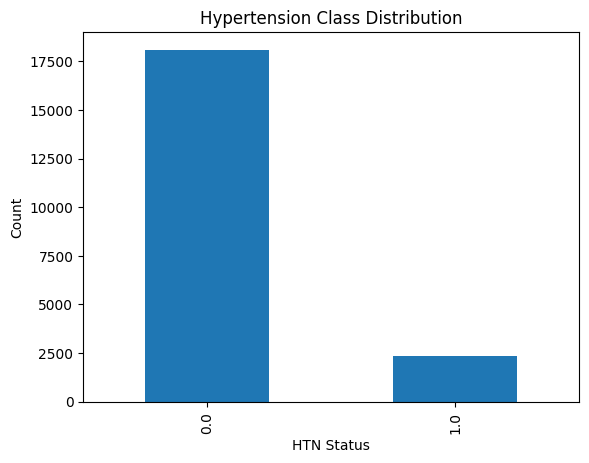

In [347]:
# ==================================================
# Visualisation of hypertension prevalence
# ==================================================

(
    model_ready_df[target_col]
    .value_counts()
    .sort_index()
    .plot(kind="bar")
)

plt.title("Hypertension Class Distribution")
plt.xlabel("HTN Status")
plt.ylabel("Count")
plt.show()

In [348]:
# ==================================================
# Create feature matrix and target vector
# ==================================================

X = model_ready_df[feature_cols]

y = model_ready_df[target_col]

print(X.shape)
print(y.shape)

(20446, 5)
(20446,)


In [349]:
# ==================================================
# Save final modelling dataset
# ==================================================

model_ready_df.to_csv(
    "../outputs/hypersense_model_ready.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


# STEP 9: EDA Summary and Modelling Recommendations

## Key Findings

- Hypertension prevalence in the modelling dataset was approximately 11.5%.
- Age demonstrated the strongest association with hypertension.
- BMI showed moderate association with hypertension but suffered substantial structural missingness.
- Tobacco use showed a weak positive association with hypertension.
- No evidence of severe multicollinearity among predictors.

## Final Feature Set

- Age
- Gender
- Residence
- Educational level
- Tobacco use

## BMI Decision

BMI was excluded from the primary model because inclusion reduced the analytical sample from 20,446 to 7,844 observations due to non-overlapping anthropometric and blood pressure measurement subsamples.

## Final Modelling Dataset

- Observations: 20,446
- Predictors: 5
- Target: htn_status
- Missing values: 0

## Models Ahead

- Logistic Regression
- Random Forest
- XGBoost

## Next Step

Notebook 04: Model Development and Evaluation